### BUILD A BASIC CHAT BOT USING LANG-GRAPH USING (GRAPH_API)

In [1]:
from typing_extensions import TypedDict
from typing  import Annotated
from langgraph.graph import StateGraph,START , END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages]
    
graph_builder  = StateGraph(State)


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
LLM = ChatGroq(
    model = "qwen/qwen3.8-27b",
    temperature = 0,
    verbose=True
)
LLM

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000176F4233770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000176F43D8590>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [25]:
def chatbot(state:State):
    return {
        "messages":[LLM.invoke(state["messages"])]
    }

In [39]:
## add nodes to graphs
graph_builder.add_node("chatbot",chatbot)
## add edges to graph
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile()




Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `chatbot` already present.

In [ ]:
##visualize the graph
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke({"messages": "hello"})
res["messages"][-1]

## Chatbot with TOOLS

In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

In [32]:

#custom funtion 

def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a (int): my first int
        b (int): second int

    Returns:
        int: output 
    """
    return a*b

In [34]:
tools = [tool,multiply]
llm_with_tools = LLM.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000176F4233770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000176F43D8590>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look 

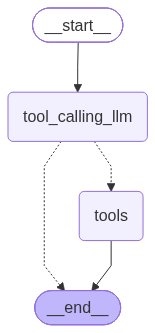

In [35]:
#creating the state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

#creating the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
res =graph.invoke({"messages":[("user","Search the web and tell me the latest OpenAI news.")]})
res["messages"][-1]

ToolMessage(content='{"query": "latest OpenAI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/09/03/open-ai-astra-gpt-6-cyber.html", "title": "OpenAI announces rollout of GPT-6 Astra model", "content": "Open AI CEO Sam Altman speaks during the G20 Innovation Ministerial in Chapel Hill, North Carolina, on September 2, 2026. \\n\\nMatt Ramey | Afp | Getty Images\\n\\nOpenAI on Thursday announced it will begin rolling out its latest artificial intelligence model, GPT-6 Astra, which the company said is the product of \\"years of research and big bets.\\"", "score": 0.83290404, "published_date": "Thu, 03 Sep 2026 18:00:02 GMT", "raw_content": null, "id": "f461bd-00"}, {"url": "https://www.newser.com/story/395861/openai-says-its-latest-release-may-mark-new-age-of-ai.html", "title": "OpenAI Says Its Latest Release May Mark New \'Age\' of AI", "content": "OpenAI says its latest creation may be the moment artificial intelligence c

In [37]:
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

Search the web and tell me the latest OpenAI news.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (th9wr279x)
 Call ID: th9wr279x
  Args:
    query: latest OpenAI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest OpenAI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/09/03/open-ai-astra-gpt-6-cyber.html", "title": "OpenAI announces rollout of GPT-6 Astra model", "content": "Open AI CEO Sam Altman speaks during the G20 Innovation Ministerial in Chapel Hill, North Carolina, on September 2, 2026. \n\nMatt Ramey | Afp | Getty Images\n\nOpenAI on Thursday announced it will begin rolling out its latest artificial intelligence model, GPT-6 Astra, which the company said is the p

In [42]:
res =graph.invoke({"messages":[("user","get me the new ai models released in 2026 and multiply 2 and 3")]})
for m in res["messages"]:
    m.pretty_print()

================================ Human Message =================================

get me the new ai models released in 2026 and multiply 2 and 3
================================== Ai Message ==================================

I'll help you with both tasks. Let me search for the latest AI models released in 2026 and calculate the multiplication.
Tool Calls:
  tavily_search (pqakrymjh)
 Call ID: pqakrymjh
  Args:
    query: new AI models released in 2026
    search_depth: advanced
    time_range: year
  multiply (a2syj7sxf)
 Call ID: a2syj7sxf
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "new AI models released in 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://llm-stats.com/llm-updates", "title": "AI Updates Today (September 2026) – Latest AI Model Releases", "content": "Track model releases from leading AI labs\n\nOpenAI\n\n### OpenAI\n\nGoogle\n\